In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


In [11]:
d = 10000
sigma = 1
n = 10

mu_1 = 0
mu_2 = d*np.power(sigma, 2)
var_1 = n*d*np.power(sigma, 2) 
var_2 = n*d*np.power(sigma, 2) + 2*d*np.power(sigma, 4)

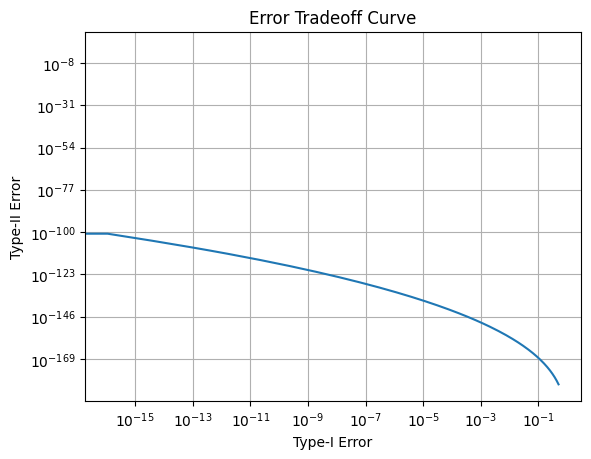

In [13]:
t_vals = np.logspace(0, 6, 500)

type_1 = 1 - norm.cdf(t_vals, mu_1, np.sqrt(var_1))
type_2=norm.cdf(t_vals, mu_2, np.sqrt(var_2))

plt.figure()
plt.loglog(type_1, type_2)
plt.xlabel("Type-I Error")
plt.ylabel("Type-II Error")
plt.title("Error Tradeoff Curve")
plt.grid(True)
plt.show()

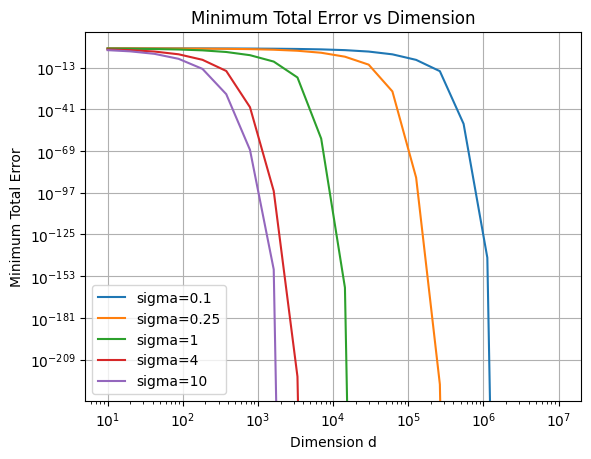

In [ ]:
dims = np.logspace(1, 7, 20).astype(int)
sigma_values = [0.1, 0.25, 1, 4, 10]

plt.figure()

for sigma in sigma_values:
    errors = []
    
    for d in dims:
        mu_1 = 0
        var_1 = n * d * sigma**2
        mu_2 = d * sigma**2
        var_2 = n * d * sigma**2 + 2 * d * sigma**4
        t_vals = np.linspace(0, mu_2 * 2, 5000)
        alpha = 1 - norm.cdf(t_vals, mu_1, np.sqrt(var_1))
        beta = norm.cdf(t_vals, mu_2, np.sqrt(var_2))
        errors.append(np.min(alpha + beta))

    plt.loglog(dims, errors, label=f"sigma={sigma}")

plt.xlabel("Dimension d")
plt.ylabel("Minimum Total Error")
plt.title("Minimum Total Error vs Dimension")
plt.legend()
plt.grid(True)
plt.show()